In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv('..\\data\\data_preprocessing.csv')

In [3]:
df.head()

,gender,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD,ratio_pression
0,male,39,level 4,No,0.0,No,No,No,No,195.0,106.0,70.0,26.97,80.0,77.0,0,1.514286
1,female,46,level 2,No,0.0,No,No,No,No,250.0,121.0,81.0,28.73,95.0,76.0,0,1.493827
2,male,48,level 1,Yes,20.0,No,No,No,No,245.0,127.5,80.0,25.34,75.0,70.0,0,1.593750
3,female,61,level 3,Yes,30.0,No,No,Yes,No,225.0,150.0,95.0,28.58,65.0,103.0,1,1.578947
4,female,46,level 3,Yes,23.0,No,No,No,No,285.0,130.0,84.0,23.10,85.0,85.0,0,1.547619


In [4]:
df.shape

(4082, 17)

In [5]:
df.columns

Index(['gender', 'age', 'education', 'currentSmoker', 'cigsPerDay', 'BPMeds',
       'prevalentStroke', 'prevalentHyp', 'diabetes', 'totChol', 'sysBP',
       'diaBP', 'BMI', 'heartRate', 'glucose', 'TenYearCHD', 'ratio_pression'],
      dtype='object')

In [6]:
df['education'] = df['education'].replace({'level 1' : 1, 'level 2' : 2, 'level 3' : 3, 'level 4' : 4})

In [7]:
colonne_categorielles = df.select_dtypes(include = "object").columns
for col in colonne_categorielles :
    df[col] = df[col].replace({"No" : 0, "Yes" : 1})

df["gender"] = df["gender"].replace({"male" : 1, "female" : 0})

In [8]:
df.head()

,gender,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD,ratio_pression
0,1,39,4,0,0.0,0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0,1.514286
1,0,46,2,0,0.0,0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0,1.493827
2,1,48,1,1,20.0,0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0,1.593750
3,0,61,3,1,30.0,0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1,1.578947
4,0,46,3,1,23.0,0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0,1.547619


In [9]:
df = df.drop('ratio_pression', axis = 1)

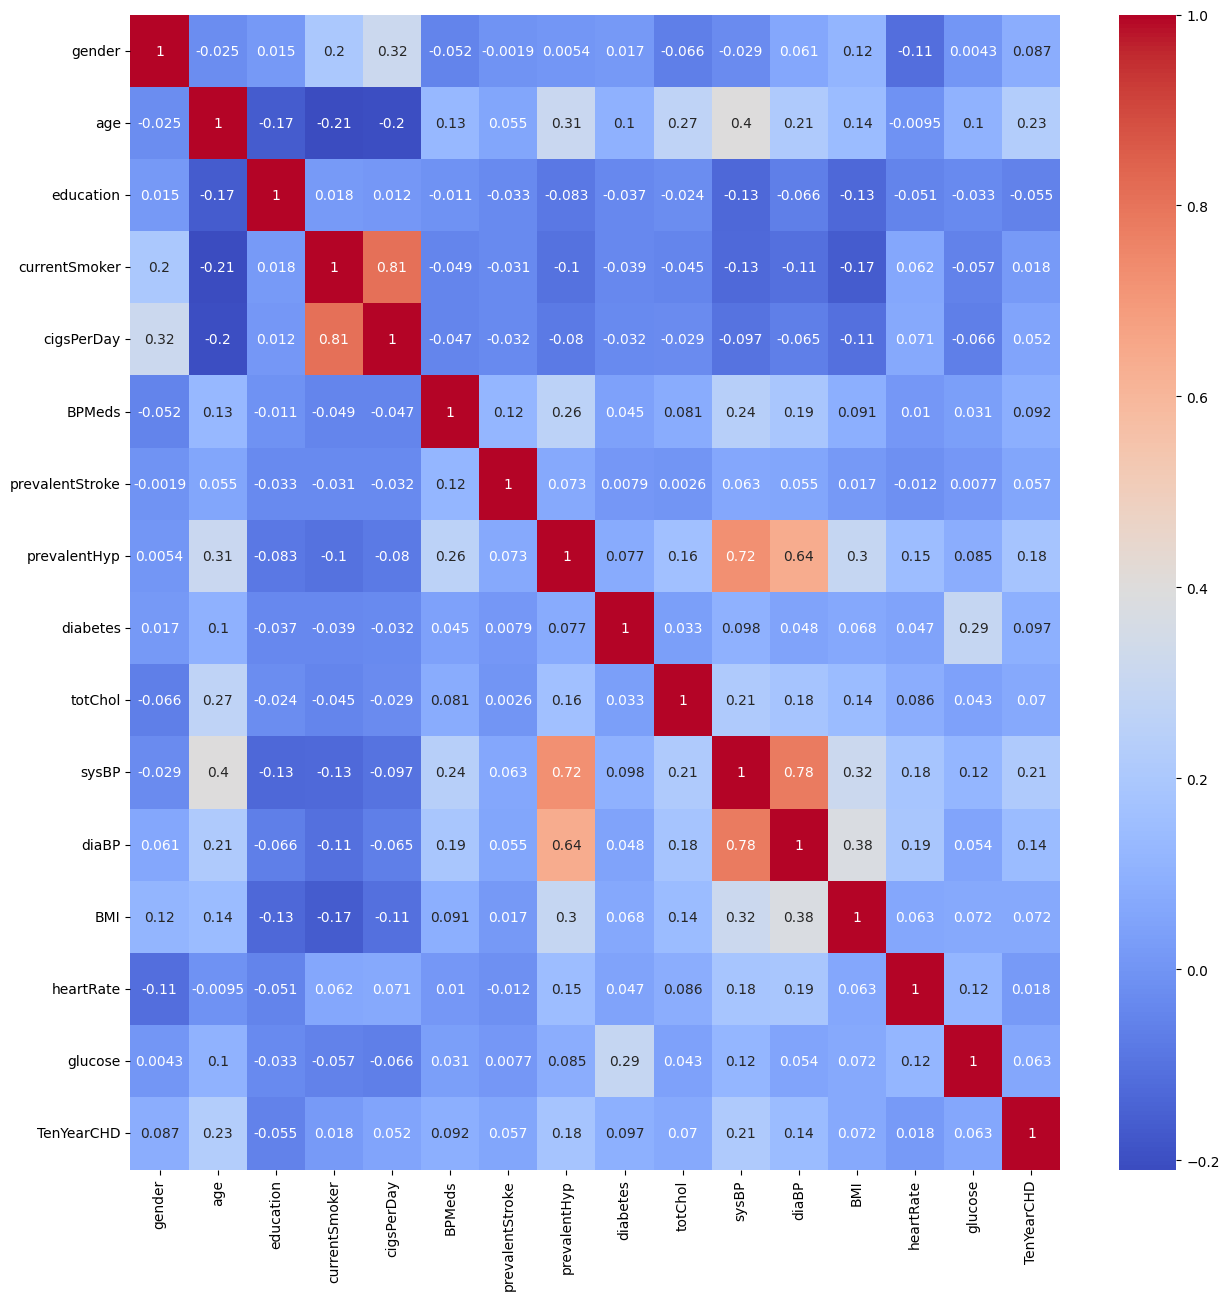

In [10]:
cor = df.corr()
plt.figure(figsize = (15, 15))
sns.heatmap(cor, annot = True, cmap = "coolwarm")
plt.show()

In [11]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

#Calcul edu VIF
X = df.drop('TenYearCHD', axis = 1)
vif_data = pd.DataFrame(
    {
        'Variable' : X.columns,
        'VIF' : [variance_inflation_factor(X.values, i) for i in range(X[X.columns].shape[1])]
    }
)
vif_data.sort_values(by = 'VIF', ascending = False)

# La pression systolique et diastolique sont dond des variables a problemes nous allons donc 
# creer un evariable pression MAP qui sera la pression arterielle moyenne et supprimer les deux
#  autres variables. 

,Variable,VIF
10,sysBP,176.889361
11,diaBP,174.122812
12,BMI,61.698349
13,heartRate,50.130776
1,age,43.551646
9,totChol,40.324804
14,glucose,38.638684
3,currentSmoker,5.876270
4,cigsPerDay,5.257205
2,education,4.722671


In [12]:
# Extraction des variables ayant une corrélation supérieure à 0.6 avec la variable d'intérêt
corr_threshold = 0.6
corr_vars = cor[abs(cor["TenYearCHD"]) > corr_threshold].index.tolist()

# Affichage des variables ayant une corrélation supérieure à 0.6 avec la variable d'intérêt
print("Variables ayant une corrélation supérieure à 0.6 avec la variable d'intérêt (TenYearCHD) :\n")
print(corr_vars)

Variables ayant une corrélation supérieure à 0.6 avec la variable d'intérêt (TenYearCHD) :

['TenYearCHD']


In [13]:

# Extraction des couples de variables ayant une corrélation supérieure à 0.8
corr_threshold = 0.8
corr_pairs = {}

for col in cor.columns:
    corr_pairs[col] = []
    corr_values = cor[abs(cor[col]) > corr_threshold][col].index.tolist()
    for pair in corr_values:
        if pair != col:
            corr_pairs[col].append(pair)

# Affichage des couples de variables ayant une corrélation supérieure à 0.8
print("Couples de variables ayant une corrélation supérieure à 0.8 :\n")
for col, pairs in corr_pairs.items():
    if len(pairs) > 0:
        for pair in pairs:
            print(col, "-", pair)

Couples de variables ayant une corrélation supérieure à 0.8 :

currentSmoker - cigsPerDay
cigsPerDay - currentSmoker


In [14]:

# Extraction des couples de variables ayant une corrélation inférieure à -0.8
corr_threshold = -0.8
corr_pairs = {}

for col in cor.columns:
    corr_pairs[col] = []
    corr_values = cor[abs(cor[col]) < corr_threshold][col].index.tolist()
    for pair in corr_values:
        if pair != col:
            corr_pairs[col].append(pair)

# Affichage des couples de variables ayant une corrélation inférieure à -0.8
print("Couples de variables ayant une corrélation inférieure à -0.8 :\n")
for col, pairs in corr_pairs.items():
    if len(pairs) > 0:
        for pair in pairs:
            print(col, "-", pair)

Couples de variables ayant une corrélation inférieure à -0.8 :



In [15]:
# Calcul de la pression arterielle moyenne
df['pression_arterielle_moyenne'] = (df['sysBP'] + 2 * df['diaBP']) / 3
df.drop(['sysBP', 'diaBP'], axis = 1, inplace = True)

In [16]:
# df["ratio_smoker_cig"] = df['cigsPerDay'] * df['currentSmoker']

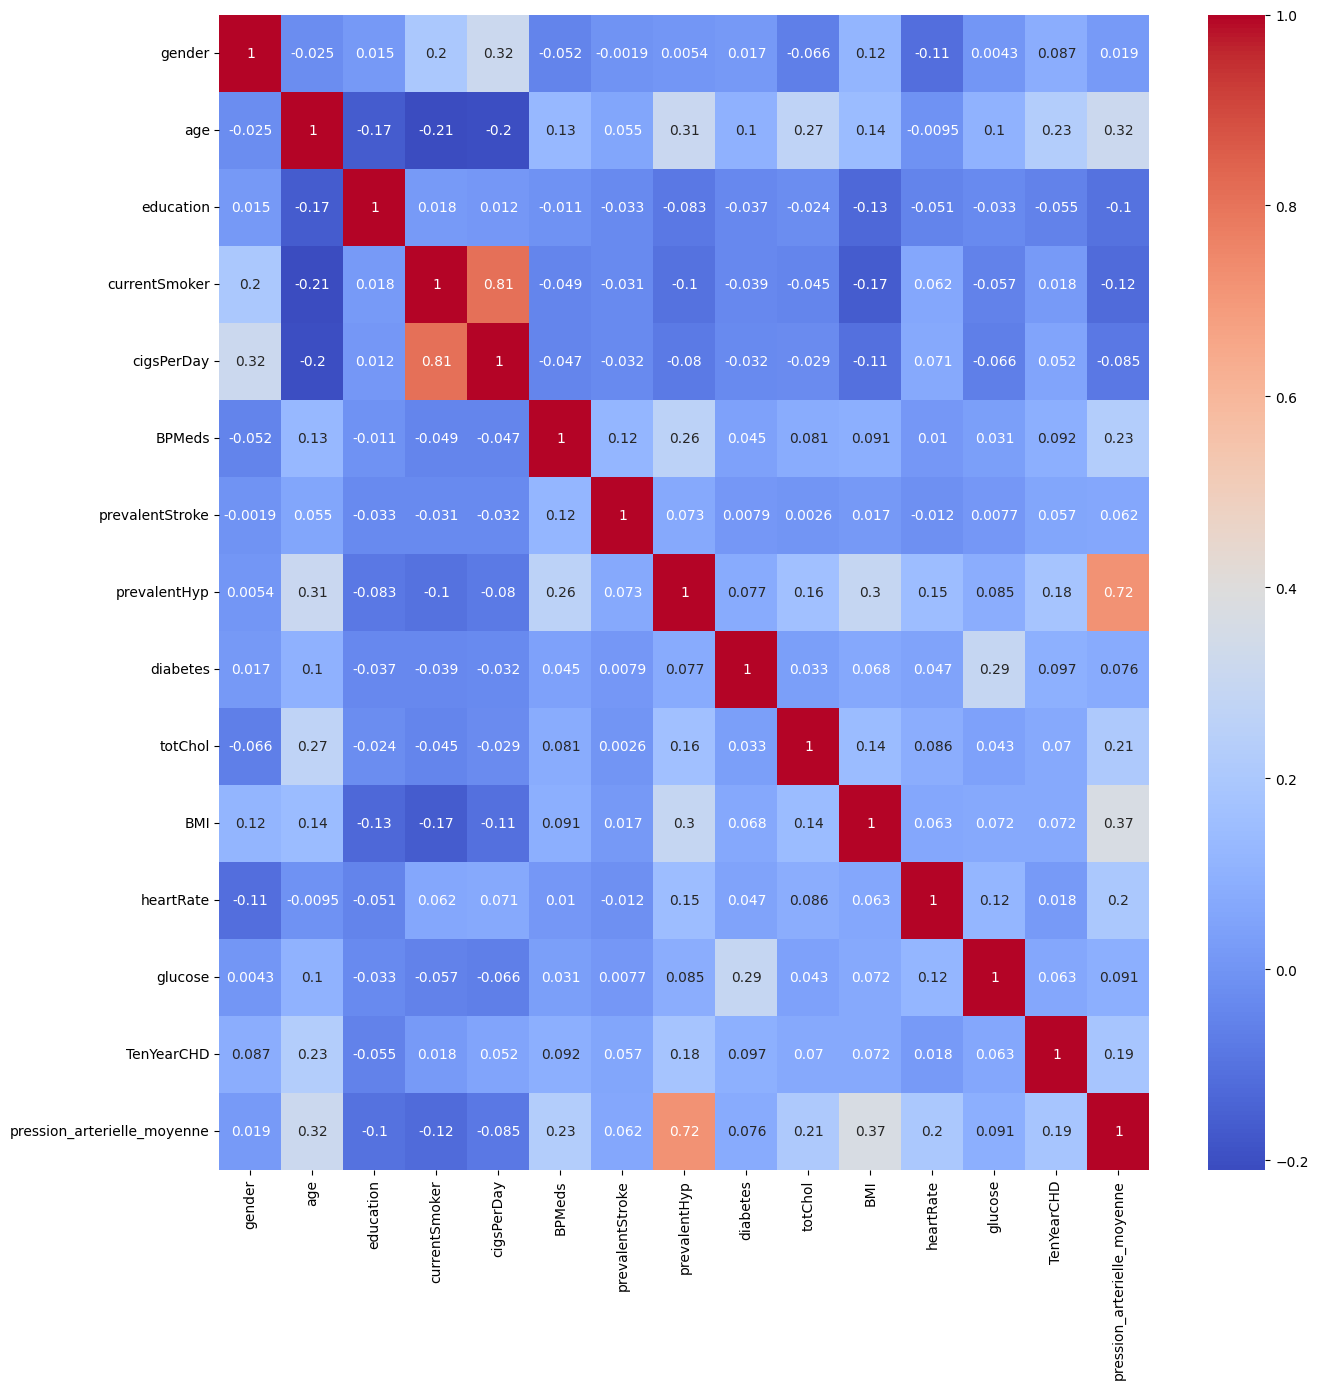

In [17]:
cor = df.corr()
plt.figure(figsize = (15, 15))
sns.heatmap(cor, annot = True, cmap = "coolwarm")
plt.show()

In [18]:
# Suppression de la colonne currentSmojer et gardons cigsPerDay, car cigsPerDay contient plus 
# d'informations que currentSmoker car si currentSmoker = 1, cigsPerDay sera forcement > 0
df = df.drop('currentSmoker', axis = 1)

In [19]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

#Calcul edu VIF
X = df.drop('TenYearCHD', axis = 1)
vif_data = pd.DataFrame(
    {
        'Variable' : X.columns,
        'VIF' : [variance_inflation_factor(X.values, i) for i in range(X[X.columns].shape[1])]
    }
)
vif_data.sort_values(by = 'VIF', ascending = False)

# La pression systolique et diastolique sont dond des variables a problemes nous allons donc 
# creer un evariable pression MAP qui sera la pression arterielle moyenne et supprimer les deux
#  autres variables. 

,Variable,VIF
12,pression_arterielle_moyenne,113.086368
9,BMI,60.448372
10,heartRate,49.906785
1,age,40.552490
8,totChol,40.283748
11,glucose,38.369775
2,education,4.679815
6,prevalentHyp,2.370166
0,gender,2.074719
3,cigsPerDay,1.952434


# Divisions du jeu de donnee

In [20]:
X = df.drop('TenYearCHD', axis = 1)
y = df['TenYearCHD']

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from imblearn.over_sampling import SMOTE



X_train, X_test, y_train, y_test = train_test_split(X, y, stratify = y, random_state = 42, test_size = 0.2)

In [22]:
y_train.value_counts()

TenYearCHD
0    2771
1     494
Name: count, dtype: int64

In [23]:
y_test.value_counts()

TenYearCHD
0    694
1    123
Name: count, dtype: int64

In [24]:
lg = LogisticRegression()

lg.fit(X_train, y_train)
y_pred = lg.predict(X_train)

In [25]:
scaler = StandardScaler()
X_train_final = scaler.fit_transform(X_train)
feature_names = scaler.get_feature_names_out()
X_train_final = pd.DataFrame(X_train_final, columns = feature_names)

X_test_final = scaler.transform(X_test)
feature_names = scaler.get_feature_names_out()
X_test_final = pd.DataFrame(X_test_final, columns = feature_names)
X_test_final.columns


#On doit appliquer SMOTE apres l'encodage et la normalisation
ratio_desire = 0.3 / 0.7
smote = SMOTE(random_state=42, sampling_strategy= ratio_desire)#'auto')#, categorical_features = [i for i in range(len(X_train.columns))])
X_train_smote, y_train_smote = smote.fit_resample(X_train_final, y_train)
y_train_smote.value_counts()

TenYearCHD
0    2771
1    1187
Name: count, dtype: int64

accuracy-score : 0.5826193390452876
precision-score : 0.6504065040650406
recall-score : 0.21164021164021163
f1-score : 0.3193612774451098
confusion-matrix : [[396  43]
 [298  80]]
classification report :               precision    recall  f1-score   support

           0       0.57      0.90      0.70       439
           1       0.65      0.21      0.32       378

    accuracy                           0.58       817
   macro avg       0.61      0.56      0.51       817
weighted avg       0.61      0.58      0.52       817

confusion _matrix: [[396 298]
 [ 43  80]]


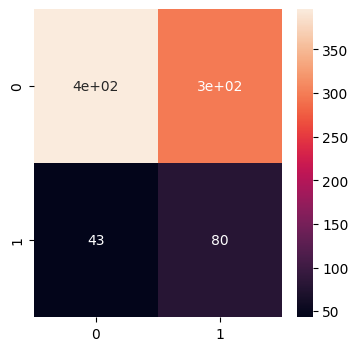

In [26]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import fbeta_score, make_scorer,accuracy_score, f1_score, precision_score, recall_score, confusion_matrix, classification_report

models = {'logistic_regression' : LogisticRegression(class_weight = "balanced", max_iter = 100)}

lg = models['logistic_regression']

def trainer(X_train, X_test, y_train, y_test, model) :
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test) 
    lg = model
    print(f'accuracy-score : {accuracy_score(y_test, y_pred)}')
    print(f'precision-score : {precision_score(y_pred, y_test)}')
    print(f'recall-score : {recall_score(y_pred, y_test)}')
    print(f'f1-score : {f1_score(y_pred, y_test)}')
    print(f'confusion-matrix : {confusion_matrix(y_pred, y_test)}')
    print(f'classification report : {classification_report(y_pred, y_test)}')
    cf_matrix = confusion_matrix(y_test,y_pred)
    plt.figure(figsize = (4, 4))
    sns.heatmap(cf_matrix, annot = True)
    print(f"confusion _matrix: {cf_matrix}")

for name in models.keys() :
    trainer(X_train, X_test, y_train, y_test, models[name]) 

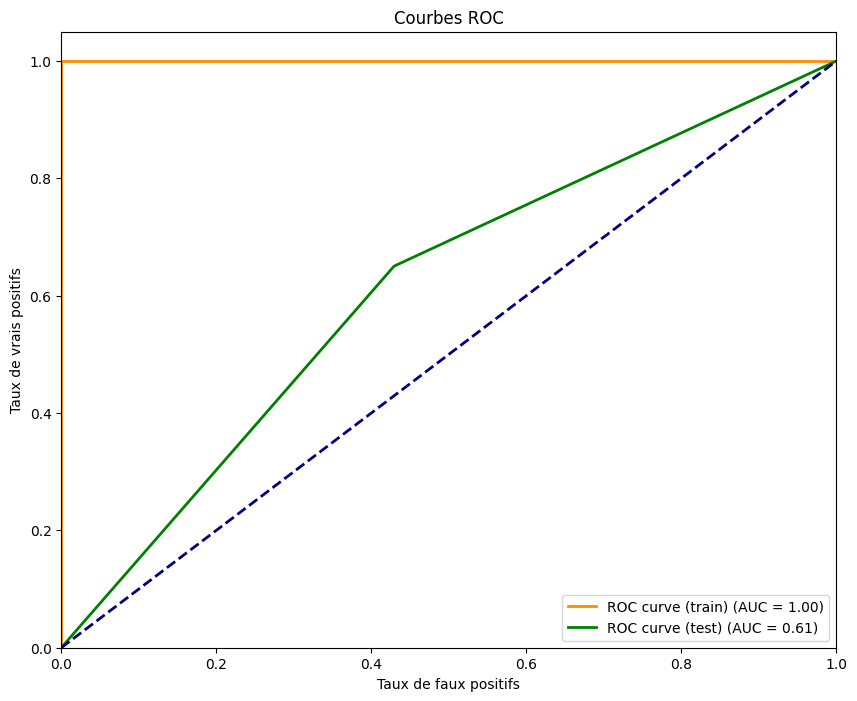

In [27]:
from sklearn.metrics import roc_curve, auc
# Obtenir les prédictions du modèle sur l'ensemble d'entraînement et de test
models['logistic_regression'].fit(X_train, y_train)

y_train_pred = models['logistic_regression'].predict(X_train)
y_test_pred = models['logistic_regression'].predict(X_test)

# Calculer les courbes ROC et les aires sous la courbe (AUC)
fpr_train, tpr_train, thresholds_train = roc_curve(y_train, y_train)
roc_auc_train = auc(fpr_train, tpr_train)

fpr_test, tpr_test, thresholds_test = roc_curve(y_test, y_test_pred)
roc_auc_test = auc(fpr_test, tpr_test)

# Tracer les courbes ROC
plt.figure(figsize=(10, 8))
plt.plot(fpr_train, tpr_train, color='darkorange', lw=2, label='ROC curve (train) (AUC = %0.2f)' % roc_auc_train)
plt.plot(fpr_test, tpr_test, color='green', lw=2, label='ROC curve (test) (AUC = %0.2f)' % roc_auc_test)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taux de faux positifs')
plt.ylabel('Taux de vrais positifs')
plt.title('Courbes ROC')
plt.legend(loc="lower right")
plt.show()

In [28]:
from sklearn.model_selection import cross_val_score, cross_validate, StratifiedKFold

#  Optimisation des hyperparamètres
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

cv_strategy = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 42)
cv_scores = cross_validate(models['logistic_regression'],
 X_train,
  y_train,
   cv = cv_strategy,
    scoring= 'recall', 
    return_train_score = True
    )
cv_score = cv_scores['test_score']
result = {}
result['scrore'] = cv_score
result['std'] = cv_score.std()
result['min'] = cv_score.min()
result['max'] = cv_score.max()
result['mean'] = cv_score.mean()

print("Au test".center(20, '*'))
print(pd.DataFrame(result))

cv_score = cv_scores['train_score']
result = {}
result['scrore'] = cv_score
result['std'] = cv_score.std()
result['min'] = cv_score.min()
result['max'] = cv_score.max()
result['mean'] = cv_score.mean()

print("Au train".center(20, '*'))
print(pd.DataFrame(result))

******Au test*******
     scrore       std       min       max      mean
0  0.585859  0.048098  0.575758  0.707071  0.633643
1  0.646465  0.048098  0.575758  0.707071  0.633643
2  0.575758  0.048098  0.575758  0.707071  0.633643
3  0.707071  0.048098  0.575758  0.707071  0.633643
4  0.653061  0.048098  0.575758  0.707071  0.633643
******Au train******
     scrore       std       min       max      mean
0  0.681013  0.011363  0.648101  0.681013  0.663464
1  0.658228  0.011363  0.648101  0.681013  0.663464
2  0.670886  0.011363  0.648101  0.681013  0.663464
3  0.648101  0.011363  0.648101  0.681013  0.663464
4  0.659091  0.011363  0.648101  0.681013  0.663464


accuracy-score : 0.6634026927784578
precision-score : 0.6910569105691057
recall-score : 0.2639751552795031
f1-score : 0.38202247191011235
confusion-matrix : [[457  38]
 [237  85]]
classification report :               precision    recall  f1-score   support

           0       0.66      0.92      0.77       495
           1       0.69      0.26      0.38       322

    accuracy                           0.66       817
   macro avg       0.67      0.59      0.58       817
weighted avg       0.67      0.66      0.62       817

confusion _matrix: [[457 237]
 [ 38  85]]


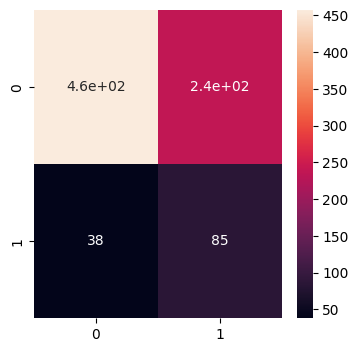

In [29]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix, classification_report
from sklearn.decomposition import PCA

models = {'logistic_regression' : LogisticRegression(class_weight = 'balanced', max_iter = 1000)}

lg = models['logistic_regression']

def trainer(X_train, X_test, y_train, y_test, model) :
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test) 
    lg = model
    print(f'accuracy-score : {accuracy_score(y_test, y_pred)}')
    print(f'precision-score : {precision_score(y_pred, y_test)}')
    print(f'recall-score : {recall_score(y_pred, y_test)}')
    print(f'f1-score : {f1_score(y_pred, y_test)}')
    print(f'confusion-matrix : {confusion_matrix(y_pred, y_test)}')
    print(f'classification report : {classification_report(y_pred, y_test)}')
    cf_matrix = confusion_matrix(y_test,y_pred)
    plt.figure(figsize = (4, 4))
    sns.heatmap(cf_matrix, annot = True)
    print(f"confusion _matrix: {cf_matrix}")

for name in models.keys() :
    trainer(X_train_smote, X_test_final, y_train_smote, y_test, models[name]) 

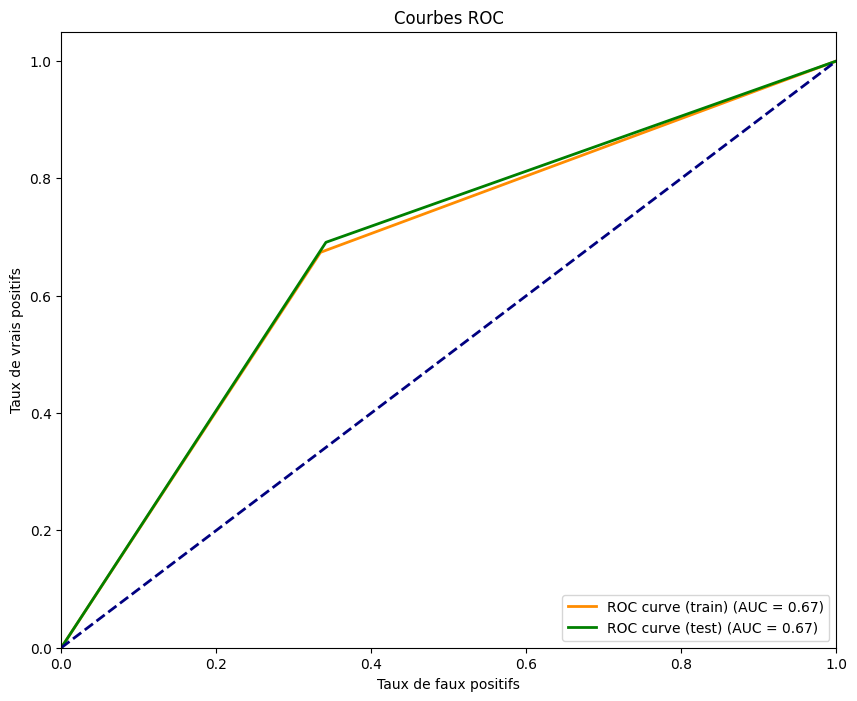

In [30]:
from sklearn.metrics import roc_curve, auc
# Obtenir les prédictions du modèle sur l'ensemble d'entraînement et de test
models['logistic_regression'].fit(X_train_smote, y_train_smote)

y_train_pred = models['logistic_regression'].predict(X_train_smote)
y_test_pred = models['logistic_regression'].predict(X_test_final)

# Calculer les courbes ROC et les aires sous la courbe (AUC)
fpr_train, tpr_train, thresholds_train = roc_curve(y_train_smote, y_train_pred)
roc_auc_train = auc(fpr_train, tpr_train)

fpr_test, tpr_test, thresholds_test = roc_curve(y_test, y_test_pred)
roc_auc_test = auc(fpr_test, tpr_test)

# Tracer les courbes ROC
plt.figure(figsize=(10, 8))
plt.plot(fpr_train, tpr_train, color='darkorange', lw=2, label='ROC curve (train) (AUC = %0.2f)' % roc_auc_train)
plt.plot(fpr_test, tpr_test, color='green', lw=2, label='ROC curve (test) (AUC = %0.2f)' % roc_auc_test)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taux de faux positifs')
plt.ylabel('Taux de vrais positifs')
plt.title('Courbes ROC')
plt.legend(loc="lower right")
plt.show()

# Validation croisee

In [31]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

#  Optimisation des hyperparamètres
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

cv_strategy = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 42)
cv_score = cross_val_score(models['logistic_regression'], X_train_smote, y_train_smote, cv = cv_strategy, scoring= 'recall')

result = {}
result['scrore'] = cv_score
result['std'] = cv_score.std()
result['min'] = cv_score.min()
result['max'] = cv_score.max()
result['mean'] = cv_score.mean()

pd.DataFrame(result)

,scrore,std,min,max,mean
0,0.693277,0.018071,0.64135,0.693277,0.667195
1,0.680672,0.018071,0.64135,0.693277,0.667195
2,0.641350,0.018071,0.64135,0.693277,0.667195
3,0.662447,0.018071,0.64135,0.693277,0.667195
4,0.658228,0.018071,0.64135,0.693277,0.667195


In [32]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, loguniform, randint


param_dist = {
    'C' : loguniform(1e-4, 1e4),
    'penalty' : ['l1', 'l2', 'elasticnet', None],
    'solver' : ['liblinear', 'newton-cg', 'lbfgs', 'sag', 'saga'],
    'class_weight' : [None, 'balanced', {0: 1, 1: 2.33}, {0: 1, 1:3}, {0 : 1, 1: 4}, {0: 1, 1: 5}],
    'l1_ratio' : uniform(0, 1),
    'fit_intercept' : [True, False],
    'tol' : loguniform(1e-5, 1e-2),
    'max_iter' : [100, 200, 500, 1000, 2000]
}

# param_dist = {
#     'model__C':            [0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1.0, 5.0],
#     'model__penalty':      ['l2'],
#     'model__class_weight': [
#         'balanced',
#         {0: 1, 1: 3},
#         {0: 1, 1: 5},
#         {0: 1, 1: 8},
#     ]
# }
# F2 : recall compte 2x plus que la précision
f2_scorer = make_scorer(fbeta_score, beta=2, pos_label=1)


random_search = RandomizedSearchCV(
    #models['logistic_regression'],
    lg,
    param_dist,
    n_iter = 100,
    cv = cv_strategy,
    scoring = 'precision',
    # scoring = {
    #     'recall' : 'recall',
    #     'f1' : 'f1', 
    #     'roc_auc' : 'roc_auc',
    #     'precision' : 'precision',
    #     'balanced_accuracy'  : 'balanced_accuracy'
    # },
    # refit = 'recall',
    n_jobs = -1,
    random_state = 42,
    verbose = 1
)

random_search.fit(X_train_smote, y_train_smote)

print(f"Best score: {random_search.best_score_:.3f}")
print(f"Best params: {random_search.best_params_}")

Fitting 5 folds for each of 100 candidates, totalling 500 fits
Best score: 0.751
Best params: {'C': np.float64(0.0005124131542371902), 'class_weight': None, 'fit_intercept': True, 'l1_ratio': np.float64(0.46077876803272577), 'max_iter': 200, 'penalty': 'l2', 'solver': 'newton-cg', 'tol': np.float64(2.4335775756765676e-05)}


accuracy-score : 0.8494492044063647
precision-score : 0.04065040650406504
recall-score : 0.5
f1-score : 0.07518796992481203
confusion-matrix : [[689 118]
 [  5   5]]
classification report :               precision    recall  f1-score   support

           0       0.99      0.85      0.92       807
           1       0.04      0.50      0.08        10

    accuracy                           0.85       817
   macro avg       0.52      0.68      0.50       817
weighted avg       0.98      0.85      0.91       817

confusion _matrix: [[689   5]
 [118   5]]


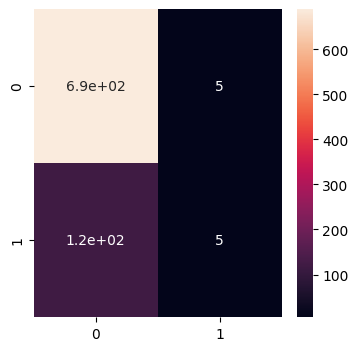

In [33]:
#Prediction avec le meilleur modele
model = LogisticRegression(**random_search.best_params_, random_state = 42)


trainer(X_train_smote, X_test_final, y_train_smote, y_test, model) 

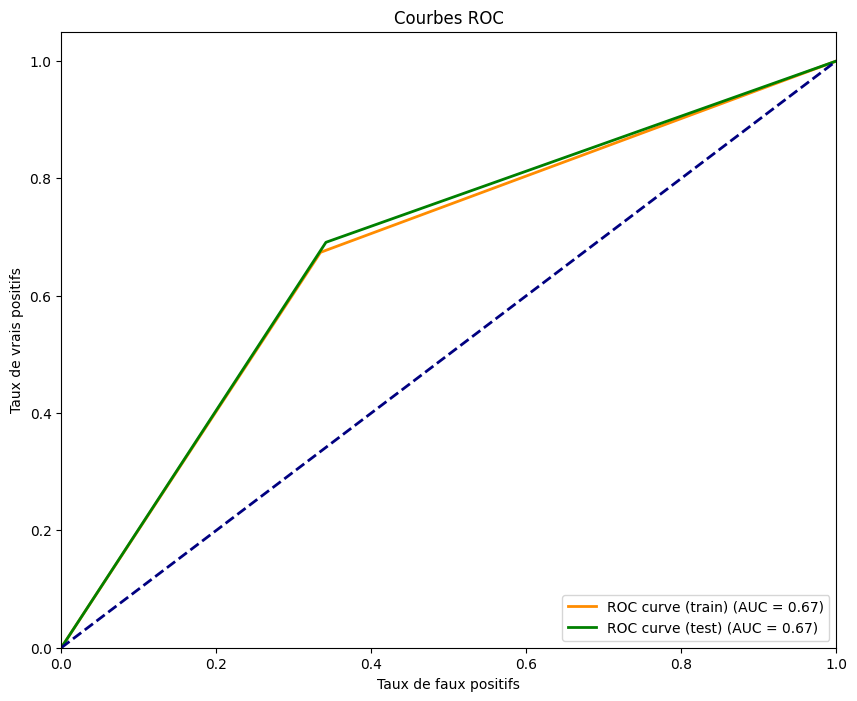

In [34]:
from sklearn.metrics import roc_curve, auc
# Obtenir les prédictions du modèle sur l'ensemble d'entraînement et de test
model.fit(X_train_smote, y_train_smote)

y_train_pred = models['logistic_regression'].predict(X_train_smote)
y_test_pred = models['logistic_regression'].predict(X_test_final)

# Calculer les courbes ROC et les aires sous la courbe (AUC)
fpr_train, tpr_train, thresholds_train = roc_curve(y_train_smote, y_train_pred)
roc_auc_train = auc(fpr_train, tpr_train)

fpr_test, tpr_test, thresholds_test = roc_curve(y_test, y_test_pred)
roc_auc_test = auc(fpr_test, tpr_test)

# Tracer les courbes ROC
plt.figure(figsize=(10, 8))
plt.plot(fpr_train, tpr_train, color='darkorange', lw=2, label='ROC curve (train) (AUC = %0.2f)' % roc_auc_train)
plt.plot(fpr_test, tpr_test, color='green', lw=2, label='ROC curve (test) (AUC = %0.2f)' % roc_auc_test)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taux de faux positifs')
plt.ylabel('Taux de vrais positifs')
plt.title('Courbes ROC')
plt.legend(loc="lower right")
plt.show()

# Optimisons le seuil de decision

In [35]:
from sklearn.metrics import precision_recall_curve

# Probabilites predites
y_proba = model.predict_proba(X_test)[:, 1]

# Courbe precision-recall pour tous les seuils possibles
precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)

# Trouver le seuil qui donne recall > 0.75 avec la meilleure precision possible
target_seuil = 0.75
valid_idx = np.where(recalls[:-1] >= target_seuil)[0]
best_idx = valid_idx[np.argmax(precisions[valid_idx])]
best_threshold = thresholds[best_idx]

print(f"Seuil optimal : {best_threshold:.3f}")
print(f"Recall : {recalls[best_idx]:.3f}")
print(f"Precision : {precisions[best_idx]:.3f}")

# Appliquer ce seuil
y_pred_custom = (y_proba >= best_threshold).astype(int)

Seuil optimal : 1.000
Recall : 0.772
Precision : 0.226


In [36]:
# Extraire les coefficients

coefficients = pd.DataFrame(
    {
        'Feature' : X_train_smote.columns,
        'Coefficient' : model.coef_[0]
    }
).sort_values(by = 'Coefficient', ascending = False)
coefficients['Importance'] = np.abs(coefficients['Coefficient'])
coefficients = coefficients.sort_values('Importance', ascending = False)
coefficients

,Feature,Coefficient,Importance
1,age,0.165030,0.165030
12,pression_arterielle_moyenne,0.102278,0.102278
6,prevalentHyp,0.087845,0.087845
0,gender,0.062639,0.062639
4,BPMeds,0.061290,0.061290
7,diabetes,0.053870,0.053870
3,cigsPerDay,0.043464,0.043464
9,BMI,0.039959,0.039959
2,education,-0.038621,0.038621
8,totChol,0.038105,0.038105


Text(0.5, 0, 'Valeur du coefficient')

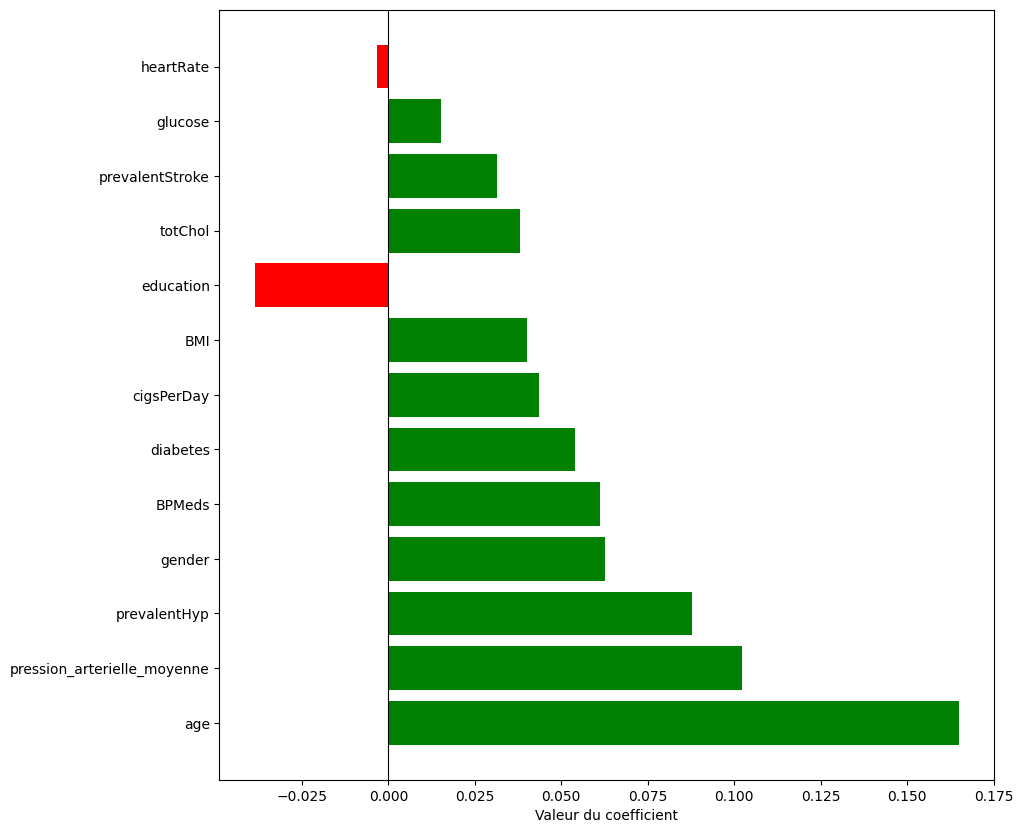

In [37]:
plt.figure(figsize = (10, 10))

colors = ['green' if c > 0 else 'red' for c in coefficients['Coefficient']]

plt.barh(coefficients['Feature'], coefficients['Coefficient'], color = colors)
plt.axvline(x = 0, color = 'black', linewidth = 0.8)
plt.xlabel("Valeur du coefficient")
# plt.tight_layout()
# plt.show()

# Calcul de l'Odds Ratio

In [38]:
# Calcul de l'Odds Ratio

coefficients['Odds_Ratio'] = np.exp(coefficients['Coefficient'])
coefficients[['Feature', 'Coefficient', 'Odds_Ratio']]

,Feature,Coefficient,Odds_Ratio
1,age,0.165030,1.179428
12,pression_arterielle_moyenne,0.102278,1.107691
6,prevalentHyp,0.087845,1.091819
0,gender,0.062639,1.064642
4,BPMeds,0.061290,1.063208
7,diabetes,0.053870,1.055348
3,cigsPerDay,0.043464,1.044422
9,BMI,0.039959,1.040768
2,education,-0.038621,0.962115
8,totChol,0.038105,1.038841


# Limites

Les limites d'un modele de machine learning sont les conditions dans lesquelles ses performances ou son interpretation se degradent. Pour mon modele de regression logistique sur framingham :
Limites Statistiques :
- Multicolinearite residuelle : Ici nous avons des VIF eleves, des coefficients instable et des OR peu fiables
- Desequilibre des classes : Modele biaise vers la classe majoritaire, memme avec SMOTE le recall est difficile a stabiliser 
- La regularisatiom biaise les OR : Ridge compresse les coefficients, tous proche de 1
- donnees manquantes 
- Generalisation geometrique : Le modele est entraine sur les donnees de ville americaine homogene(majorite blanche) il peut donc mal generalise sur d'autres populations.

# Deploiement 

In [40]:
import joblib

joblib.dump(model,          'model.pkl',          compress=3)

['model.pkl']

In [46]:
joblib.dump(model,          'model_only.pkl',     compress=3)
joblib.dump(best_threshold, 'best_threshold.pkl', compress=3)

print("\n model_only.pkl     → instance LogisticRegression")
print(f" best_threshold.pkl → seuil = {best_threshold:.4f}")
print("\n  Rappel : le prétraitement doit être reproduit")
print("   manuellement dans app.py avant predict_proba()")


 model_only.pkl     → instance LogisticRegression
 best_threshold.pkl → seuil = 1.0000

  Rappel : le prétraitement doit être reproduit
   manuellement dans app.py avant predict_proba()
